In [4]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines  # needed for custom legend markers
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
%matplotlib inline

In [5]:
gpd.options.io_engine = "pyogrio" #faster engine

rf= r"C:/Projects/GeoChem-DataLab/raw_data/markgeokemi_regional.gpkg"

raw = gpd.read_file(
    rf,
    layer = "moran_0063mm_hno3_icpms", # moran_0063mm_hno3_icpms  
    use_arrow = True
)
#Drop rows with missing ID/coordinates & ensure SWEREF system 
df_clean = raw.dropna(   
    subset=[
        "unikt_id", "ns", "ew", "geometry"
    ]).set_crs("EPSG:3006", allow_override=True) 
# save cleaned data to GeoPackage
df_clean.to_file(
     "C:/Projects/GeoChem-DataLab/cleaned_data/df_clean.gpkg",
    driver= "GPKG",
    use_arrow = True
) 
# 4.1 Filter: keep only rows with valid, positive As/Fe/Ca/Al/U
# (0 = "not analyzed" per SGU product description; excluded by > 0)
df_markgeodata = df_clean[
    (df_clean["as_ppm"].notna()) & (df_clean["as_ppm"] > 0) &   # As: valid, positive only
    (df_clean["fe_ppm"].notna()) & (df_clean["fe_ppm"] > 0) &   # Fe: valid, positive only
    (df_clean["ca_ppm"].notna()) & (df_clean["ca_ppm"] > 0) &   # Ca: valid, positive only
    (df_clean["al_ppm"].notna()) & (df_clean["al_ppm"] > 0) &   # Al: valid, positive only
    (df_clean["u_ppm"].notna())  & (df_clean["u_ppm"] > 0)      # U: valid, positive only
][[
    "unikt_id", "ns", "ew",
    "as_ppm", "fe_ppm", "ca_ppm", "al_ppm", "u_ppm",
    "geometry"]].copy()  # keep only needed columns; independent copy

print(f"Analysis-ready sample points: {len(df_markgeodata)}")  # expect ~28,470

C:\Users\Admin\anaconda3\Lib\site-packages\pyogrio\geopandas.py:346: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["geometry"] = shapely.from_wkb(wkb_values, on_invalid=on_invalid)


Analysis-ready sample points: 27981


As: 75th = 3.90 ppm, 95th = 13.00 ppm


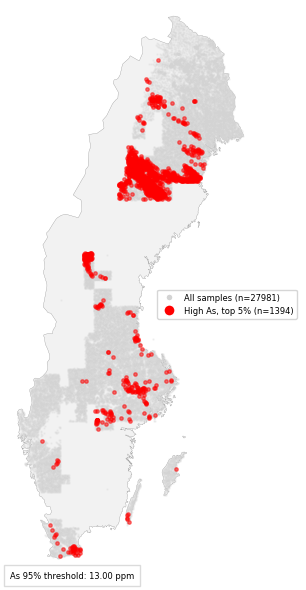

In [9]:
# Arsenic
#---------------------
world = gpd.read_file(
    r"C:/Projects/GeoChem-DataLab/raw_data/ne_110m_admin_0_countries/ne_10m_admin_0_countries.shp"
)#spf of country boundary polygon: ne_10m_admin_0_countries.shp
sweden = world[world["ADMIN"] == "Sweden"].to_crs("EPSG:3006") #Sweden's boundary polygon

# Relative screening: 75th and 95th percentile thresholds
as_p75 = df_markgeodata["as_ppm"].quantile(0.75)
as_p95 = df_markgeodata["as_ppm"].quantile(0.95)
print(f"As: 75th = {as_p75:.2f} ppm, 95th = {as_p95:.2f} ppm")

#using Numpy, create a new as_class column
#labels each data, high, medium, low, based on as_75 and as_95
df_markgeodata["as_class"] = np.select( 
    [df_markgeodata["as_ppm"] > as_p95, df_markgeodata["as_ppm"] > as_p75],
    ["High", "Medium"],
    default="Low"
)

df_markgeodata["as_hotspot"] = df_markgeodata["as_ppm"] > as_p95 #create a bolean as_hotspot (P95) column
as_high = df_markgeodata[df_markgeodata["as_hotspot"]] # a subset, 5% only
fig, ax = plt.subplots(figsize=(4, 6))
sweden.plot(ax=ax, edgecolor="grey", facecolor="#f2f2f2", linewidth=0.2)#Sweden outline
df_markgeodata.plot(ax=ax, color="lightgrey", markersize=0.5, alpha=0.25)# draw data as dots on Sweden base map
as_high.plot(ax=ax, color="red", markersize=6, alpha=0.5) #plot hotspots, red

minx, miny, maxx, maxy = sweden.total_bounds #get sweden bbox. in meters, since it is in EPSG:3006
pad = 20000  # 20 km margin
ax.set_xlim(minx - pad, maxx + pad) # crop x-axis to Sweden + padding
ax.set_ylim(miny - pad, maxy + pad) # crop y-axis to Sweden + padding

legend_elements = [                                            # build custom legend entries
    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"All samples (n={len(df_markgeodata)})",
                  markerfacecolor="lightgrey", markersize=5),
    mlines.Line2D([0], [0], marker="o", color="w",              # hide x/y axis lines/ticks
                  label=f"High As, top 5% (n={len(as_high)})",
                  markerfacecolor="red", markersize=8)
]
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(0.6, 0.5),# place legend outside plot
          borderaxespad=0.3, fontsize=6, frameon=True)
ax.set_axis_off()
ax.text(
    0.0, -0.01,
    f"As 95% threshold: {as_p95:.2f} ppm",
    transform=ax.transAxes,
    fontsize=6,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="lightgrey")
)
plt.tight_layout()
fig.savefig(
    r"C:/Projects/GeoChem-DataLab/results/arsenic_screening_map.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [13]:
len(raw)
#len(df_clean)
#len(df_markgeodata)

28471

As: 75th = 3.90 ppm, 95th = 13.00 ppm
As: KM guideline = 10.00 ppm, MKM guideline = 25.00 ppm
as_guideline_class
Below KM     25862
KM–MKM        1752
Above MKM      367
Name: count, dtype: int64


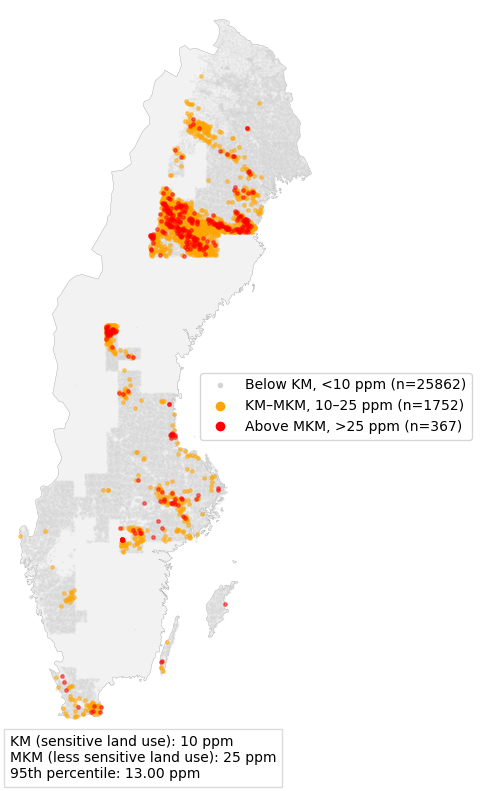

In [10]:
# ARSENIC — Guideline-based screening (Naturvårdsverket KM/MKM)
# ==============================================================
AS_KM = 10.0   # sensitive land use (homes/schools/gardens), mg/kg TS
AS_MKM = 25.0  # less sensitive land use (offices/industry), mg/kg TS

as_p75 = df_markgeodata["as_ppm"].quantile(0.75)
as_p95 = df_markgeodata["as_ppm"].quantile(0.95)
print(f"As: 75th = {as_p75:.2f} ppm, 95th = {as_p95:.2f} ppm")
print(f"As: KM guideline = {AS_KM:.2f} ppm, MKM guideline = {AS_MKM:.2f} ppm")

df_markgeodata["as_guideline_class"] = np.select(
    [df_markgeodata["as_ppm"] > AS_MKM, df_markgeodata["as_ppm"] > AS_KM],
    ["Above MKM", "KM–MKM"],
    default="Below KM"
)
below_km = df_markgeodata[df_markgeodata["as_guideline_class"] == "Below KM"]
km_mkm   = df_markgeodata[df_markgeodata["as_guideline_class"] == "KM–MKM"]
above_mkm = df_markgeodata[df_markgeodata["as_guideline_class"] == "Above MKM"]
print(df_markgeodata["as_guideline_class"].value_counts())

# ==============================================================
# Map: Arsenic vs. Naturvårdsverket guideline values
# ==============================================================
fig, ax = plt.subplots(figsize=(6, 8))
sweden.plot(ax=ax, edgecolor="grey", facecolor="#f2f2f2", linewidth=0.2)
below_km.plot(ax=ax, color="lightgrey", markersize=0.5, alpha=0.25)
km_mkm.plot(ax=ax, color="orange", markersize=6, alpha=0.5)
above_mkm.plot(ax=ax, color="red", markersize=6, alpha=0.5)

minx, miny, maxx, maxy = sweden.total_bounds
pad = 20000
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

legend_elements = [
    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"Below KM, <{AS_KM:.0f} ppm (n={len(below_km)})",
                  markerfacecolor="lightgrey", markersize=5),
    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"KM–MKM, {AS_KM:.0f}–{AS_MKM:.0f} ppm (n={len(km_mkm)})",
                  markerfacecolor="orange", markersize=8),
    mlines.Line2D([0], [0], marker="o", color="w",
                  label=f"Above MKM, >{AS_MKM:.0f} ppm (n={len(above_mkm)})",
                  markerfacecolor="red", markersize=8)
]
ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(0.6, 0.5),
          borderaxespad=0.3, fontsize=10, frameon=True)
ax.set_axis_off()

ax.text(
    0.0, -0.01,
    f"KM (sensitive land use): {AS_KM:.0f} ppm\n"
    f"MKM (less sensitive land use): {AS_MKM:.0f} ppm\n"
    f"95th percentile: {as_p95:.2f} ppm",
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="lightgrey")
)
plt.tight_layout()
fig.savefig(
    r"C:/Projects/GeoChem-DataLab/results/arsenic_guideline_screening_map.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [16]:
df_markgeodata.head()

,unikt_id,ns,ew,as_ppm,fe_ppm,ca_ppm,al_ppm,u_ppm,geometry,as_class,as_hotspot
1,"XX00.05001.Morän finfraktion (< 0,063 mm)",6426662.0,341104.0,2.0,11431.0,1276.0,9528.0,1.6,POINT (341104 6426662),Low,False
2,"XX00.05002.Morän finfraktion (< 0,063 mm)",6424548.0,341066.0,1.5,10501.0,2430.0,7855.0,1.6,POINT (341066 6424548),Low,False
3,"XX00.05003.Morän finfraktion (< 0,063 mm)",6422304.0,341028.0,1.3,14749.0,1216.0,9055.0,2.2,POINT (341028 6422304),Low,False
4,"XX00.05004.Morän finfraktion (< 0,063 mm)",6428703.0,343978.0,1.2,5063.0,1736.0,6322.0,0.9,POINT (343978 6428703),Low,False
5,"XX00.05005.Morän finfraktion (< 0,063 mm)",6426516.0,343613.0,1.6,9327.0,2374.0,6468.0,1.6,POINT (343613 6426516),Low,False
